# Day 1 — Data Pipeline

**Goal**: Pull clean OHLCV data for 10 stocks (2018–2024), verify quality, and persist to `data/`.

| Field | Value |
|-------|-------|
| Tickers | AAPL, MSFT, GOOGL, AMZN, JPM, BAC, XOM, JNJ, TSLA, NVDA |
| Date range | 2018-01-01 → 2024-12-31 |
| Source | yfinance (auto-adjusted) |
| Output | `data/ohlcv_<TICKER>.csv`, `data/prices.csv`, `data/returns.csv` |

In [1]:
# ─── Notebook setup ─────────────────────────────────────────────────────────
import sys, os
from pathlib import Path

# Add project root to path so we can import src.*
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Premium plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       120,
})

ACCENT_COLORS = [
    '#58a6ff', '#3fb950', '#f78166', '#d2a8ff',
    '#ffa657', '#79c0ff', '#56d364', '#ff7b72',
    '#e3b341', '#bc8cff'
]

print('Environment ready ✓')

Environment ready ✓


## 1. Load Data

In [2]:
from src.data.loader import DataLoader

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'BAC', 'XOM', 'JNJ', 'TSLA', 'NVDA']

loader = DataLoader(
    tickers=TICKERS,
    start='2018-01-01',
    end='2024-12-31',
)

ohlcv = loader.load(force_download=True)

22:59:18 | INFO | DataLoader | Loading data for 10 tickers | 2018-01-01 → 2024-12-31



22:59:42 | INFO | DataLoader | Loaded 10 / 10 tickers successfully.


## 2. Data Quality Summary

In [3]:
summary = loader.summary()
print('=== Data Quality Summary ===')
print(summary.to_string())
print(f'\nAll tickers loaded: {len(ohlcv)} / {len(TICKERS)}')
print(f'NaN rows remaining: {summary["NaN_total"].sum()}')

=== Data Quality Summary ===
             Start         End  Rows  NaN_total  Close_mean  Close_std
Ticker                                                                
AAPL    2018-01-02  2024-12-30  1760          0      121.55      58.95
MSFT    2018-01-02  2024-12-30  1760          0      234.84     105.98
GOOGL   2018-01-02  2024-12-30  1760          0      100.67      38.69
AMZN    2018-01-02  2024-12-30  1760          0      129.26      38.82
JPM     2018-01-02  2024-12-30  1760          0      122.98      37.69
BAC     2018-01-02  2024-12-30  1760          0       29.53       6.43
XOM     2018-01-02  2024-12-30  1760          0       68.10      25.84
JNJ     2018-01-02  2024-12-30  1760          0      133.14      18.58
TSLA    2018-01-02  2024-12-30  1760          0      157.95     112.31
NVDA    2018-01-02  2024-12-30  1760          0       28.80      35.54

All tickers loaded: 10 / 10
NaN rows remaining: 0


## 3. Sample: AAPL OHLCV

In [4]:
aapl = ohlcv['AAPL']
print(f'AAPL shape: {aapl.shape}')
print(f'Index type: {type(aapl.index[0])}')
print()
print('First 5 rows:')
display(aapl.head())
print('Last 5 rows:')
display(aapl.tail())

AAPL shape: (1760, 5)
Index type: <class 'pandas.Timestamp'>

First 5 rows:


Price,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,39.776182,40.276423,39.565798,40.267071,102223600
2018-01-03,40.330191,40.802382,40.196951,40.260063,118071600
2018-01-04,40.332529,40.549925,40.225002,40.447071,89738400
2018-01-05,40.542909,40.994059,40.451743,40.907570,94640000
2018-01-08,40.755630,41.050164,40.657449,40.755630,82271200


Last 5 rows:


Price,Open,High,Low,Close,Volume
Date,,,,,
2024-12-23,253.152588,254.026991,251.840961,253.649414,40858800
2024-12-24,253.868019,256.570737,253.669277,256.560822,23234700
2024-12-26,256.550893,258.448771,255.994450,257.375610,27237100
2024-12-27,256.193177,257.057679,251.453470,253.967407,42355300
2024-12-30,250.628701,251.890642,249.158101,250.598892,35557500


## 4. Price History — All 10 Stocks (Normalized)

22:59:42 | INFO | DataLoader | Price matrix shape: (1760, 10)  (trading days × tickers)


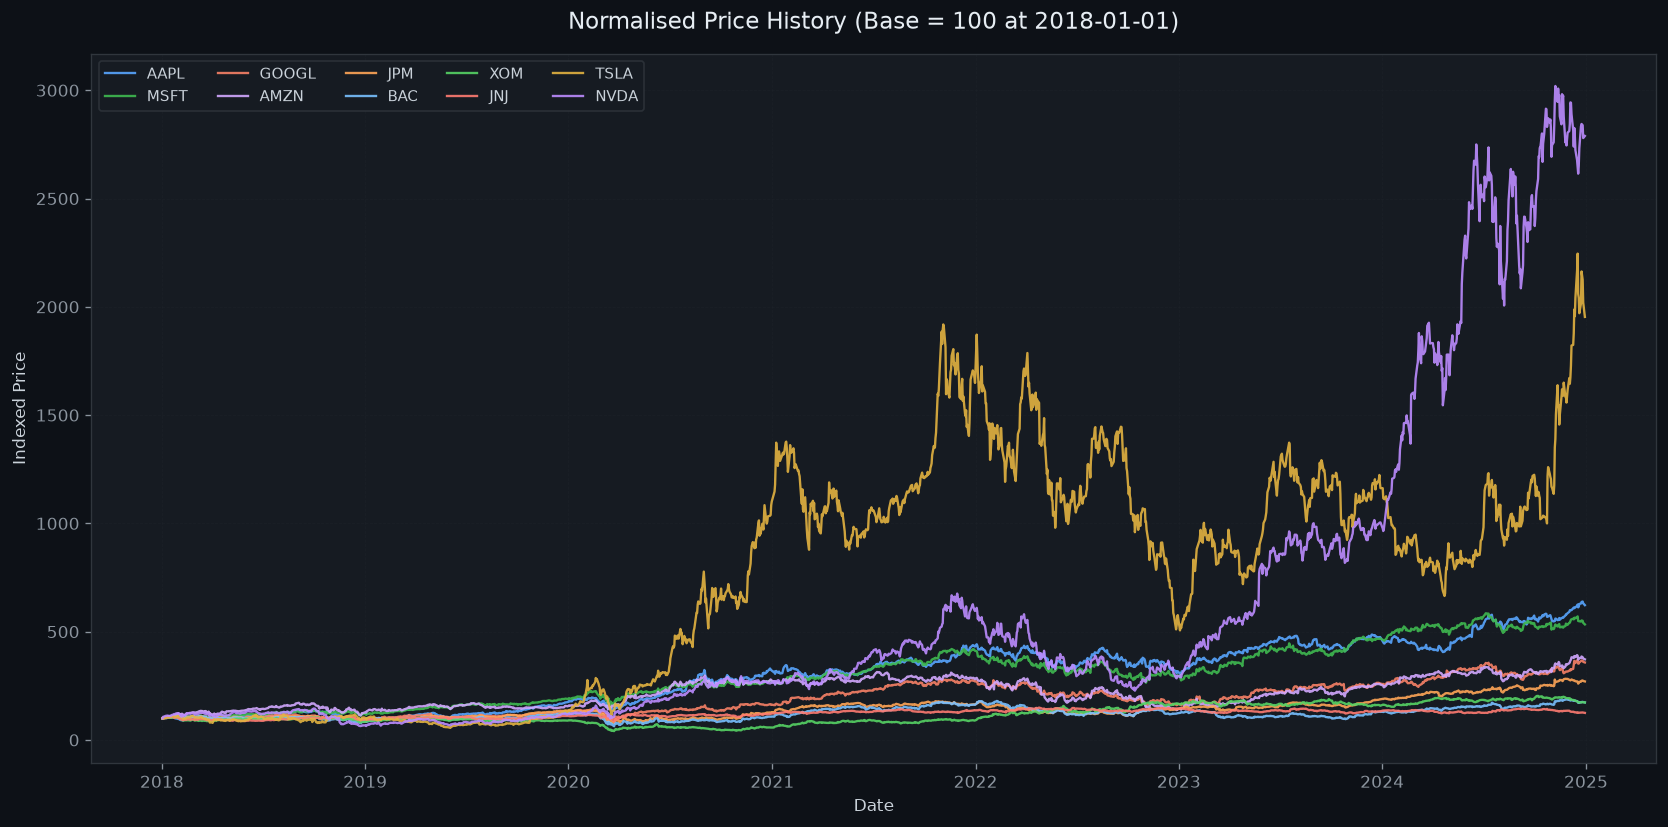

Chart saved → reports/day1_normalised_prices.png


In [5]:
prices = loader.get_prices()

# Normalise to 100 at start for visual comparison
norm = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))

for i, ticker in enumerate(norm.columns):
    ax.plot(norm.index, norm[ticker], label=ticker,
            color=ACCENT_COLORS[i], linewidth=1.4, alpha=0.9)

ax.set_title('Normalised Price History (Base = 100 at 2018-01-01)',
             fontsize=14, pad=15, color='#e6edf3')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(ncol=5, loc='upper left', fontsize=9,
          facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../reports/day1_normalised_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → reports/day1_normalised_prices.png')

## 5. Daily Returns Distribution

22:59:43 | INFO | DataLoader | Price matrix shape: (1760, 10)  (trading days × tickers)


22:59:43 | INFO | DataLoader | Returns matrix shape: (1759, 10)


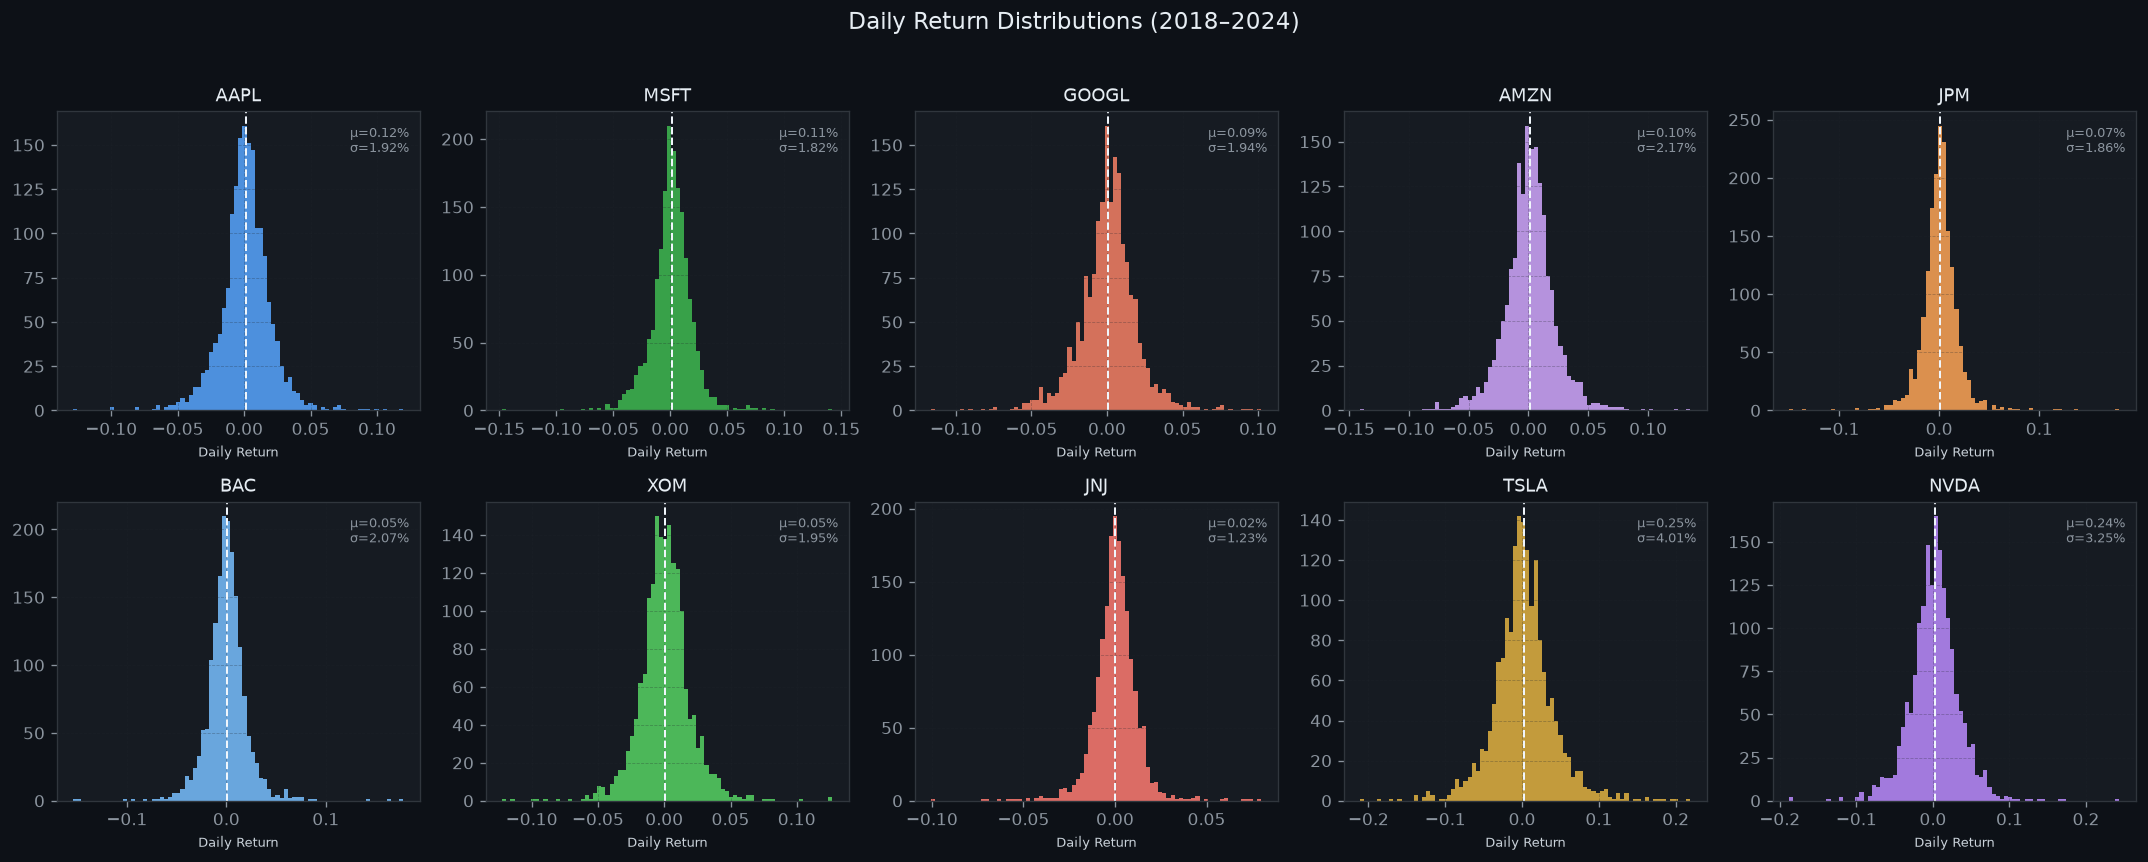

Chart saved → reports/day1_return_distributions.png


In [6]:
returns = loader.get_returns()

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(returns.columns):
    ax = axes[i]
    r = returns[ticker].dropna()
    ax.hist(r, bins=80, color=ACCENT_COLORS[i], alpha=0.85, edgecolor='none')
    ax.axvline(r.mean(), color='#f0f6fc', linewidth=1.2, linestyle='--', label='Mean')
    ax.set_title(ticker, fontsize=11, color='#e6edf3')
    ax.set_xlabel('Daily Return', fontsize=8)
    stats_text = f'μ={r.mean()*100:.2f}%\nσ={r.std()*100:.2f}%'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right', color='#8b949e')
    ax.grid(True, alpha=0.3)

fig.suptitle('Daily Return Distributions (2018–2024)', fontsize=14,
             color='#e6edf3', y=1.02)
plt.tight_layout()
plt.savefig('../reports/day1_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → reports/day1_return_distributions.png')

## 6. Correlation Heatmap

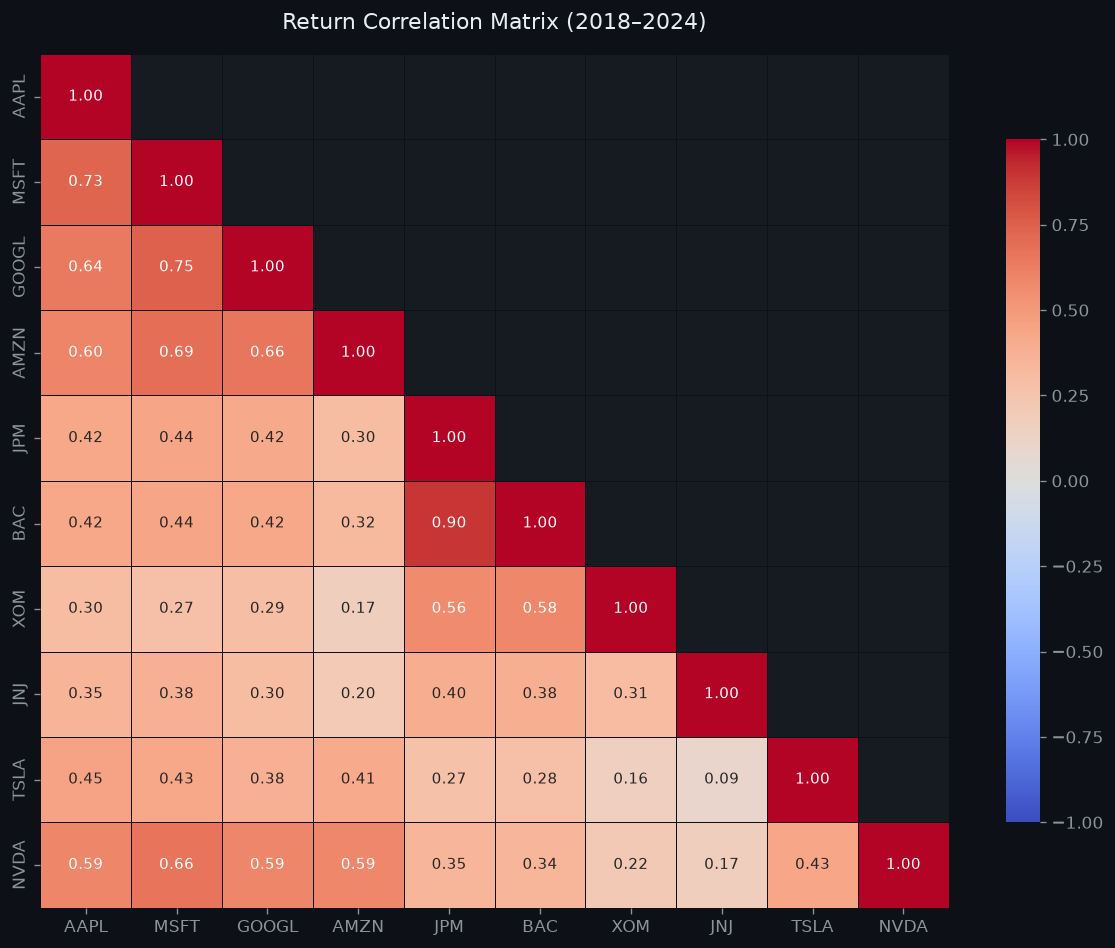

Chart saved → reports/day1_correlation_heatmap.png


In [7]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#0d1117',
    annot_kws={'size': 9},
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Return Correlation Matrix (2018–2024)',
             fontsize=13, pad=15, color='#e6edf3')
plt.tight_layout()
plt.savefig('../reports/day1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → reports/day1_correlation_heatmap.png')

## 7. Annualised Stats Table

In [8]:
TRADING_DAYS = 252

stats = pd.DataFrame({
    'Ann. Return (%)':    (returns.mean() * TRADING_DAYS * 100).round(2),
    'Ann. Volatility (%)': (returns.std() * np.sqrt(TRADING_DAYS) * 100).round(2),
    'Sharpe (rf=0)':       ((returns.mean() * TRADING_DAYS) / (returns.std() * np.sqrt(TRADING_DAYS))).round(3),
    'Max Daily Loss (%)':  (returns.min() * 100).round(2),
    'Max Daily Gain (%)':  (returns.max() * 100).round(2),
    'Skewness':            returns.skew().round(3),
    'Kurtosis':            returns.kurt().round(3),
})

print('=== Annualised Statistics (2018–2024) ===')
display(stats)

=== Annualised Statistics (2018–2024) ===


,Ann. Return (%),Ann. Volatility (%),Sharpe (rf=0),Max Daily Loss (%),Max Daily Gain (%),Skewness,Kurtosis
AAPL,30.87,30.55,1.010,-12.86,11.98,-0.009,5.122
MSFT,28.17,28.89,0.975,-14.74,14.22,-0.023,6.797
GOOGL,23.01,30.79,0.747,-11.63,10.22,-0.064,3.884
AMZN,24.76,34.42,0.719,-14.05,13.54,0.033,3.976
JPM,18.61,29.60,0.629,-14.96,18.01,0.413,13.901
BAC,13.23,32.81,0.403,-15.40,17.80,0.422,10.984
XOM,12.66,30.99,0.408,-12.22,12.69,0.048,5.420
JNJ,5.10,19.57,0.261,-10.04,8.00,-0.204,9.138
TSLA,62.80,63.71,0.986,-21.06,21.92,0.273,3.579
NVDA,60.97,51.54,1.183,-18.76,24.37,0.159,4.481


## 8. Save All Data

In [9]:
loader.save()
print()

import os
data_files = list(Path('../data').glob('*.csv'))
print(f'Files in data/: {len(data_files)}')
for f in sorted(data_files):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<30} {size_kb:>7.1f} KB')

22:59:48 | INFO | DataLoader |   Saved AAPL → C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AAPL.csv


22:59:48 | INFO | DataLoader |   Saved MSFT → C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_MSFT.csv


22:59:48 | INFO | DataLoader |   Saved GOOGL → C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_GOOGL.csv


22:59:48 | INFO | DataLoader |   Saved AMZN → C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AMZN.csv


22:59:48 | INFO | DataLoader |   Saved JPM → C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_JPM.csv


...

22:59:48 | INFO | DataLoader | Combined prices saved → C:\Users\Asus\Desktop\algo-trading-system\data\prices.csv


22:59:48 | INFO | DataLoader | Price matrix shape: (1760, 10)  (trading days × tickers)


22:59:48 | INFO | DataLoader | Returns matrix shape: (1759, 10)


22:59:48 | INFO | DataLoader | Daily returns saved  → C:\Users\Asus\Desktop\algo-trading-system\data\returns.csv



Files in data/: 12
  ohlcv_AAPL.csv                   163.7 KB
  ohlcv_AMZN.csv                   156.8 KB
  ohlcv_BAC.csv                    163.1 KB
  ohlcv_GOOGL.csv                  162.3 KB
  ohlcv_JNJ.csv                    163.0 KB
  ohlcv_JPM.csv                    161.9 KB
  ohlcv_MSFT.csv                   162.7 KB
  ohlcv_NVDA.csv                   164.3 KB
  ohlcv_TSLA.csv                   159.6 KB
  ohlcv_XOM.csv                    161.2 KB
  prices.csv                       334.8 KB
  returns.csv                      387.3 KB


## ✅ Day 1 Complete

| Deliverable | Status |
|------------|--------|
| Clean OHLCV for 10 tickers | ✅ |
| Zero NaN rows | ✅ |
| Aligned price matrix | ✅ |
| Daily returns matrix | ✅ |
| Saved to `data/` | ✅ |
| Charts in `reports/` | ✅ |

**Next**: Day 2 — Technical Indicators + Signal Generation → `notebooks/day2_signals.ipynb`